In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
from google.colab import drive

drive.mount('/content/drive')

train_dir = '/content/drive/MyDrive/problemds/train'
val_dir   = '/content/drive/MyDrive/problemds/val'
test_dir  = '/content/drive/MyDrive/problemds/test'

Mounted at /content/drive


In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Classes:", train_ds.class_names)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [13]:
model = Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels from [0,255] to [0,1]
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Feature vector
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,201 (2.35 MB)

 Trainable params: 615,201 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [16]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [20]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7116 - loss: 0.6086 - precision: 0.7294 - recall: 0.9568
Epoch 1: val_loss improved from None to 0.80554, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1510s 9s/step - accuracy: 0.7391 - loss: 0.5866 - precision: 0.7429 - recall: 0.9923 - val_accuracy: 0.5000 - val_loss: 0.8055 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7359 - loss: 0.5745 - precision: 0.7377 - recall: 0.9939
Epoch 2: val_loss improved from 0.80554 to 0.58382, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 289ms/step - accuracy: 0.7504 - loss: 0.5486 - precision: 0.7581 - recall: 0.9752 - val_accuracy: 0.6250 - val_loss: 0.5838 - val_precision: 0.5833 - val_recall: 0.8750
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accurac

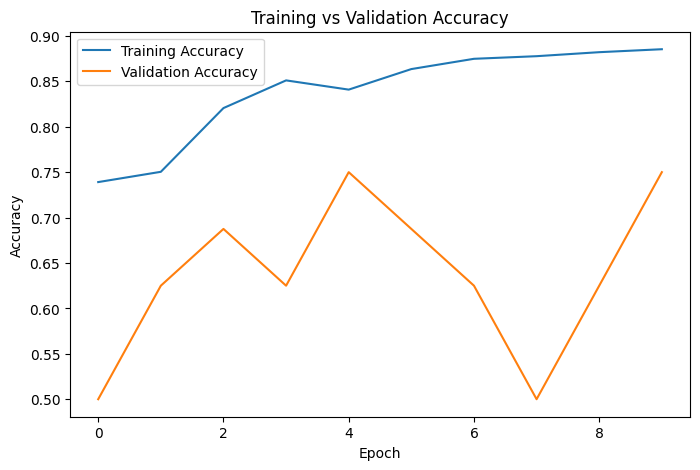

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

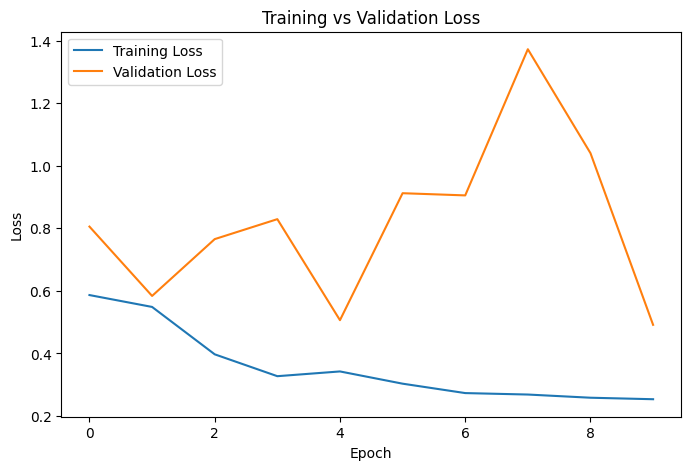

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [22]:
best_model = keras.models.load_model("best_cnn_model.keras")

In [23]:
test_results = best_model.evaluate(test_ds, verbose=1)

print("\nTest Results:")

for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 180s 9s/step - accuracy: 0.8125 - loss: 0.3906 - precision: 0.9027 - recall: 0.7846

Test Results:
loss: 0.3906
compile_metrics: 0.8125


In [28]:
y_true = []
y_pred_prob = []

for images, labels in test_ds:

    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert probability to class
y_pred = (y_pred_prob >= 0.5).astype(int)

In [29]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8125
Precision: 0.9026548672566371
Recall   : 0.7846153846153846
F1 Score : 0.8395061728395061


In [26]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      NORMAL       0.71      0.86      0.77       234
   PNEUMONIA       0.90      0.78      0.84       390

    accuracy                           0.81       624
   macro avg       0.80      0.82      0.81       624
weighted avg       0.83      0.81      0.82       624

